# Missing Data Handling: A Hands-On Project

Real datasets are rarely complete, and the way values go missing is rarely random in the way people assume. This notebook works through a synthetic health dataset built with three different missingness mechanisms baked in on purpose, so you can see what each one actually looks like in practice, not just in a definition.

`bmi` is missing completely at random. `glucose` is missing depending on `income_bracket` (an observed variable). `blood_pressure` is missing depending on its own value (high readings are more likely to be missing) — and that last one is the hardest case, because you can't directly observe what you don't have.

By the end, you'll have compared three imputation strategies (`SimpleImputer`, `KNNImputer`, `IterativeImputer`), tested whether missingness indicator columns help, and built a saved, reusable pipeline that does all of it without leaking test data into training.


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(7)
n = 800

df = pd.DataFrame({
    "age": np.random.randint(20, 80, n),
    "bmi": np.random.normal(26, 5, n),
    "blood_pressure": np.random.normal(120, 18, n),
    "glucose": np.random.normal(95, 20, n),
    "smoking_status": np.random.choice(
        ["never", "former", "current"], n
    ),
    "income_bracket": np.random.choice(
        ["low", "mid", "high"], n
    ),
    "hospital_visits": np.random.poisson(1.5, n),
    "has_condition": np.random.binomial(1, 0.25, n)
})

mask_mcar = np.random.rand(n) < 0.12
df.loc[mask_mcar, "bmi"] = np.nan

mask_mar = df["income_bracket"] == "low"
df.loc[
    mask_mar & (np.random.rand(n) < 0.35),
    "glucose"
] = np.nan

mask_mnar = df["blood_pressure"] > 145
df.loc[
    mask_mnar & (np.random.rand(n) < 0.4),
    "blood_pressure"
] = np.nan

df.to_csv("day02_health.csv", index=False)
print(df.shape)

(800, 8)


## Section 1: Initial Data Exploration

Same discipline as any new dataset: know the shape, the types, what's missing and how much, before deciding anything about how to handle it.


In [1]:
df.shape

(800, 8)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   bmi              721 non-null    float64
 2   blood_pressure   772 non-null    float64
 3   glucose          707 non-null    float64
 4   smoking_status   800 non-null    object 
 5   income_bracket   800 non-null    object 
 6   hospital_visits  800 non-null    int64  
 7   has_condition    800 non-null    int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 50.1 KB


Three columns have fewer non-null entries than the 800 rows: `bmi` (721), `blood_pressure` (772), `glucose` (707). That's the first concrete clue something's missing, before even running `.isnull().sum()` explicitly.

In [ ]:
df.isnull().sum()

age                 0
bmi                79
blood_pressure     28
glucose            93
smoking_status      0
income_bracket      0
hospital_visits     0
has_condition       0
dtype: int64


In [2]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_pct

age                0.00
bmi                9.88
blood_pressure     3.50
glucose            11.62
smoking_status     0.00
income_bracket     0.00
hospital_visits    0.00
has_condition      0.00
dtype: float64

Three different missing percentages: `glucose` at 11.62%, `bmi` at 9.88%, `blood_pressure` at 3.50%. None of these is large enough to consider dropping the column outright (a common rule of thumb is to start worrying around 40-50%+), but they're all large enough that ignoring the missingness (e.g., letting it crash a model, or silently dropping rows) would throw away a meaningful chunk of data.

In [3]:
df.describe()

              age         bmi  blood_pressure     glucose  hospital_visits  has_condition
count  800.000000  721.000000      772.000000  707.000000       800.000000     800.000000
mean    49.990000   25.896078      117.810940   95.158200         1.490000       0.231250
std     17.335456    4.849974       16.925701   20.374134         1.183914       0.421896
min     20.000000   11.763933       63.175101   18.136970         0.000000       0.000000
25%     35.000000   22.676523      106.132123   81.424708         1.000000       0.000000
50%     50.000000   25.985495      117.793968   95.144198         1.000000       0.000000
75%     65.000000   29.136199      129.094955  109.520389         2.000000       0.000000
max     74.000000   42.417575      173.437292  149.661282         6.000000       1.000000

Worth noticing here, and easy to miss: `.describe()` only summarizes the rows that *aren't* missing for each column, since `count` already shows 721/772/707 instead of 800. That means every statistic above (mean, std, percentiles) describes the observed subset, not the full population. This matters most for `blood_pressure`: its observed mean is 117.81, even though it was generated from a Normal(120, 18) distribution. That gap, observed mean below the true generating mean, is itself a clue about the missingness mechanism, which Section 2 will come back to.

`age` and `hospital_visits` have zero missing values, both fully observed.

In [4]:
df['smoking_status'].value_counts(normalize=True)

smoking_status
current    0.3575
never      0.3350
former     0.3075
Name: proportion, dtype: float64

In [5]:
df['income_bracket'].value_counts(normalize=True)

income_bracket
low     0.3525
high    0.3275
mid     0.3200
Name: proportion, dtype: float64

In [6]:
df['has_condition'].value_counts(normalize=True)

has_condition
0    0.76875
1    0.23125
Name: proportion, dtype: float64

`has_condition`, the target, sits at roughly 23% positive, 77% negative. Moderate imbalance, not severe, but enough that `stratify=y` matters later and that a metric like accuracy alone would be misleading (a model that always predicts "no condition" gets ~77% accuracy while being useless).

**Common mistake:** computing missing percentages but not checking whether they cluster in particular rows or relate to other columns. A column being "only 10% missing" sounds mild until you discover that 10% is concentrated entirely within one subgroup, which changes what you should do about it. Section 2 digs into exactly that.

**Reflection:** the observed `blood_pressure` mean (117.81) is noticeably below the value used to generate the data (120). What does that gap suggest about which values are more likely to be missing — high ones, low ones, or neither?

## Section 2: Understanding Missingness Mechanisms

Here's the thing that trips people up first: missing data has structure. It's tempting to treat every gap in a spreadsheet the same way — "just fill it in somehow" — but *why* a value is missing changes what filling it in even means.

Think of it like a survey. If a question got skipped because the printer jammed and randomly dropped a few answers from random people, that's noise: nothing about the people who skipped it differs systematically from the people who answered. But if a question about income got skipped disproportionately by low-income respondents who felt uncomfortable answering, the missingness itself is telling you something about the people who are missing. Same blank cell on the page, completely different meaning underneath it.

**The three categories:**

| Type | Definition | Example | Difficulty |
|---|---|---|---|
| MCAR (Missing Completely At Random) | The probability of being missing has nothing to do with any observed or unobserved value | A lab sample gets dropped due to a random equipment glitch | Easiest — missingness is just noise, doesn't bias estimates |
| MAR (Missing At Random) | The probability of being missing depends on *observed* variables, but not on the missing value itself | Lower-income patients are less likely to get a glucose test done (depends on observed `income_bracket`, not on what their glucose level actually is) | Moderate — recoverable if you account for the variables it depends on |
| MNAR (Missing Not At Random) | The probability of being missing depends on the *missing value itself* (or something unobserved correlated with it) | High blood pressure readings are disproportionately missing, because patients in a hypertensive crisis get sent for emergency care before a routine reading is logged | Hardest — the data needed to "explain" the missingness is exactly the data that's gone |

**Why MCAR is the easiest case:** since missingness doesn't depend on anything, the people with missing data are, statistically, a random sample of everyone. Drop them or impute them with a simple summary statistic, and you're not introducing systematic bias, just losing some precision.

**Why MAR requires understanding relationships between variables:** the missingness isn't random, but it's at least explainable using data you have. If you know glucose missingness depends on `income_bracket`, you can use that relationship (e.g., impute using group-specific means, or use a model that includes income as a predictor) and recover something close to unbiased estimates.

**Why MNAR is the hardest case:** the missingness depends on the very thing you don't have. You can't directly verify "are high blood pressure readings more likely to be missing" by checking the missing values, because you don't have them. You're stuck inferring it indirectly, often from outside domain knowledge (e.g., knowing how the data was collected) rather than from the data itself.

**Why no statistical test can definitively prove MAR or MNAR:** a test can show that missingness correlates with an *observed* variable, which is evidence consistent with MAR. But it can never rule out MNAR, because MNAR depends on the unobserved value, and you have no way to check correlation against something you don't have. The honest position is usually "the evidence is consistent with MAR" or "I have no observed-variable explanation, so I suspect MNAR, but I can't prove it" — not a clean yes/no answer.

**Reflection:** if you discovered that `glucose` missingness depended on `age` instead of `income_bracket`, would that still be MAR? What would have to be true for it to be MNAR instead?

## Section 3: Visualizing Missingness

Numbers like "9.88% missing" don't show you *where* the gaps are, whether they cluster, or whether they line up with another column. A visualization can make a pattern obvious in two seconds that would take a dozen `.groupby()` calls to confirm numerically. Visualize first, then verify with statistics.

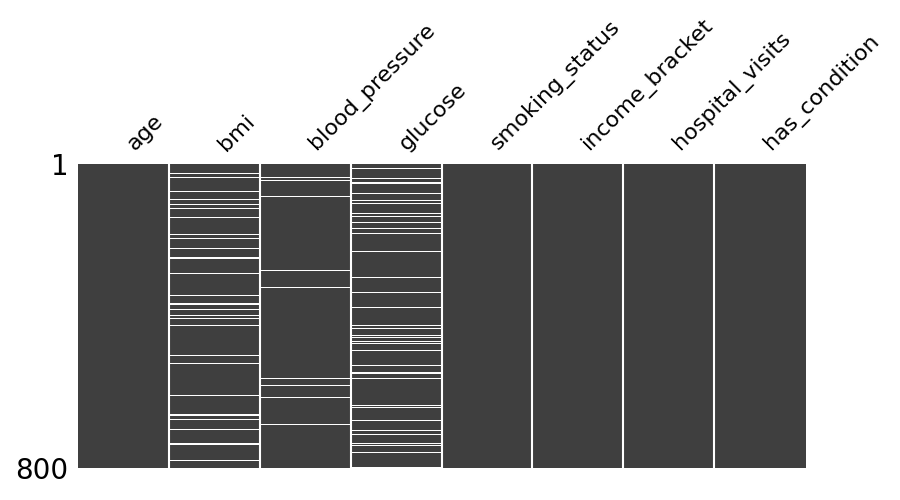

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)
plt.tight_layout()
plt.show()

Each white gap is a missing value, plotted in row order. Look at `glucose`: the gaps aren't scattered evenly down the column, they cluster into visible bands. That clustering is itself a clue — since the rows weren't shuffled after generation, the rows with `income_bracket == "low"` sit together, and that's exactly where `glucose`'s missingness concentrates. `bmi`'s gaps, by contrast, look scattered with no obvious banding, consistent with missingness that doesn't depend on row order or any grouping variable. `blood_pressure` has the sparsest, most scattered gaps of the three, which fits with only 3.5% missing overall.

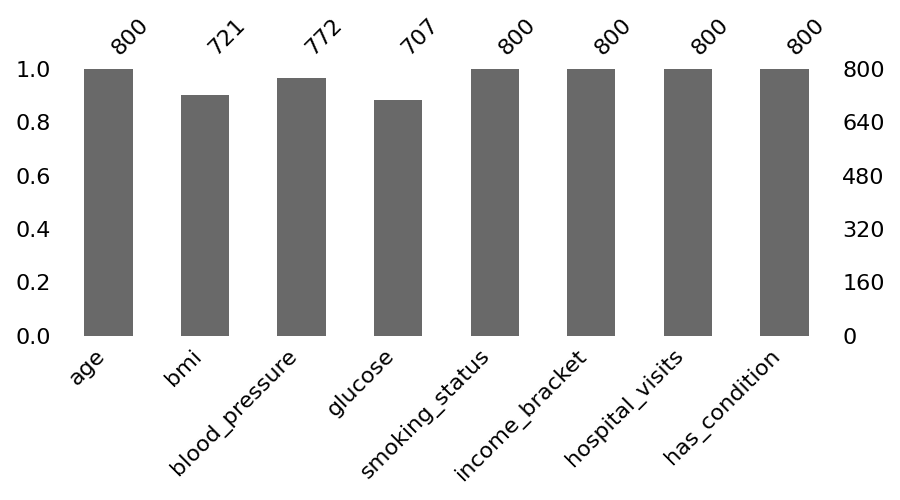

In [ ]:
msno.bar(df)
plt.tight_layout()
plt.show()

A simpler view of the same information as `.isnull().sum()`, just visual: `age`, `smoking_status`, `income_bracket`, `hospital_visits`, and `has_condition` are fully populated at 800. `bmi`, `blood_pressure`, and `glucose` show their non-null counts as shorter bars. Useful as a quick first glance before diving into matrix or correlation views.

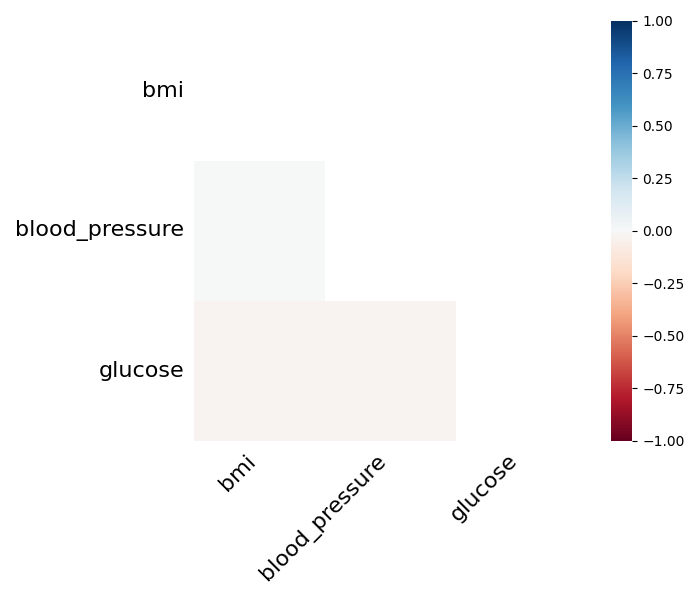

In [ ]:
msno.heatmap(df)
plt.tight_layout()
plt.show()

This one is specifically about whether missingness in one column correlates with missingness in *another* column (not with the columns' actual values — that's a different check, coming in Section 4). The values here are all close to 0, meaning whether `bmi` is missing tells you almost nothing about whether `blood_pressure` or `glucose` is also missing for that same row. That's expected given how the three masks were generated independently of each other in the data-generating code. If you saw a strong positive value here, it would suggest some shared cause behind multiple columns going missing together (e.g., an entire lab panel failing at once, taking several test results down with it).

**Common mistake:** treating this correlation heatmap as if it tells you whether missingness correlates with the *underlying values* of other columns (which is what would reveal MAR). It doesn't; it only compares missingness patterns to each other. The MAR evidence for `glucose` (its relationship to `income_bracket`) doesn't show up here at all, because `income_bracket` itself isn't missing — you need Section 4's groupby/crosstab approach to catch that.

**Reflection:** if `bmi` and `blood_pressure` had shown a strong positive correlation in the missingness heatmap, what real-world data collection process might explain that (think about how health data actually gets recorded)?

## Section 4: Investigating Missingness Types

Visualization gives you a hunch. This section turns the hunch into something closer to evidence, by creating an indicator column for each feature with missingness, then checking whether that indicator relates to other variables you can actually observe.

In [7]:
df["bmi_missing"] = df["bmi"].isna().astype(int)
df["blood_pressure_missing"] = df["blood_pressure"].isna().astype(int)
df["glucose_missing"] = df["glucose"].isna().astype(int)

df[["bmi_missing", "blood_pressure_missing", "glucose_missing"]].mean()

bmi_missing               0.098750
blood_pressure_missing    0.035000
glucose_missing           0.116250
dtype: float64

These three numbers should match the missing percentages from Section 1 (9.88%, 3.50%, 11.62%), just expressed as proportions instead of percentages — a quick sanity check that the indicator columns are correct.

### Is glucose missingness associated with income_bracket?

In [8]:
df.groupby('income_bracket')['glucose_missing'].mean()

income_bracket
high    0.000000
low     0.329787
mid     0.000000
Name: glucose_missing, dtype: float64

This is about as clear a MAR signal as you'll find: 0% missing for `high` and `mid` income, 33% missing for `low` income. Glucose missingness depends entirely on an observed variable (`income_bracket`), which is the textbook definition of MAR. In a real dataset this pattern might reflect, for example, low-income patients having less consistent access to lab testing — the missingness reflects something about the healthcare system, not anything about the patients' actual glucose levels.

In [9]:
pd.crosstab(df['income_bracket'], df['glucose_missing'], normalize='index')

glucose_missing         0         1
income_bracket                     
high             1.000000  0.000000
low              0.670213  0.329787
mid              1.000000  0.000000

Same information as the groupby, formatted as proportions within each income group (`normalize='index'` means each row sums to 1). Useful when you want to present "of the low-income patients, what fraction are missing glucose" rather than the reverse.

### Is bmi missingness associated with any variable?

In [ ]:
print("BMI missing rate by income bracket:")
print(df.groupby('income_bracket')['bmi_missing'].mean())
print()
print("BMI missing rate by smoking status:")
print(df.groupby('smoking_status')['bmi_missing'].mean())

BMI missing rate by income bracket:
income_bracket
high    0.125954
low     0.063830
mid     0.109375
Name: bmi_missing, dtype: float64

BMI missing rate by smoking status:
smoking_status
current    0.090909
former     0.101626
never      0.104478
Name: bmi_missing, dtype: float64


Compare this to the glucose result: there's no clean 0%-vs-33% split here, just values clustered loosely between 6% and 13% across both groupings, with no obvious pattern (the `low` income group actually has the *lowest* BMI missing rate, not the highest, so there's no consistent direction even). That looseness, missingness hovering around the overall rate (9.88%) regardless of which group you slice by, is consistent with MCAR: nothing observed seems to predict it.

**Important nuance:** this doesn't *prove* MCAR. It only fails to find evidence against it. There could be some unmeasured variable driving `bmi` missingness that this dataset doesn't capture. "Consistent with MCAR" is the right phrase, not "proven to be MCAR." That said, this particular dataset's BMI missingness actually *is* MCAR by construction (a uniform random draw, unrelated to anything), so the absence of a pattern here is the correct, true conclusion in this specific case.

### What clues suggest blood_pressure is MNAR?

In [ ]:
print("BP missing rate by age decade:")
df['age_decade'] = (df['age'] // 10) * 10
print(df.groupby('age_decade')['blood_pressure_missing'].mean())
print()
print("Observed (non-missing) blood_pressure summary:")
print(df['blood_pressure'].describe())

BP missing rate by age decade:
age_decade
20    0.053030
30    0.016807
40    0.020979
50    0.047244
60    0.040000
70    0.031008
Name: blood_pressure_missing, dtype: float64

Observed (non-missing) blood_pressure summary:
count    772.000000
mean     117.810940
std       16.925701
min       63.175101
25%      106.132123
50%      117.793968
75%      129.094955
max      173.437292
Name: blood_pressure, dtype: float64


Notice what's *missing* from this investigation, by necessity: there's no clean groupby that reveals the mechanism the way `income_bracket` revealed it for glucose, because the actual driver (`blood_pressure` itself being above 145) isn't something you can group by when the values are gone. Age doesn't predict it (no clear trend across decades, ranging narrowly from 1.7% to 5.3%). No other observed column in this dataset predicts it either.

The real clue is structural, not statistical: the observed mean (117.81) sits below what you'd expect from a population centered at 120 (the generating mean, which you wouldn't normally know, but the gap itself is the signal worth noticing even without that knowledge — a distribution that "should" look symmetric but doesn't quite). If high values were being selectively removed, you'd expect exactly this: an observed distribution that looks shifted downward and slightly truncated at the top relative to what a symmetric, complete distribution would look like. The max observed value, 173.4, also isn't impossibly far from what you'd expect if the true distribution extended further but got cut off by the missingness mechanism.

None of this *proves* MNAR. It's circumstantial: no observed variable explains it, and the shape of what remains looks like a population with its upper tail thinned out. That's the most you can usually say about suspected MNAR without external information about how the data was actually collected.

**Limitations of detecting MNAR, stated plainly:** you can rule things in (confirm MAR when a clean dependency on an observed variable shows up, like glucose/income) but you can't rule MNAR in or out with certainty. The honest workflow is: check every observed variable for a relationship to the missingness indicator. If you find one, that's evidence for MAR (though it doesn't rule out additional unobserved drivers). If you find nothing, you're left choosing between "probably MCAR" and "probably MNAR, but unprovable from this data alone" — and that choice usually has to come from domain knowledge about *how* the data was collected, not from the dataset itself.

**Common mistake:** running one groupby, finding nothing, and concluding "must be MCAR." Absence of an observed-variable relationship is consistent with both MCAR and MNAR; it doesn't distinguish between them. The only way `glucose` got correctly identified as MAR above is that `income_bracket` happened to be a variable we thought to check, and it happened to be in the dataset. If it hadn't been, glucose's missingness would have looked exactly as unexplainable as blood_pressure's does.

**Reflection:** suppose this dataset hadn't included `income_bracket` at all. Re-reading Section 4 without that column, would you have been able to tell `glucose`'s missingness apart from `bmi`'s? What does that imply about the limits of missingness diagnosis when you don't have every relevant variable on hand?

## Section 5: Train-Test Split and Leakage Prevention

Same principle as encoding and scaling leakage from Day 1, applied to imputation specifically: **split before you fit anything that learns from the data**, including an imputer.

**What leaks during imputation, specifically:** a `SimpleImputer` with `strategy='mean'` computes a column average. If that average is computed using the full dataset, test rows have contributed to the value used to fill in missing training rows. A `KNNImputer` looks at the nearest neighbors *across whatever dataset it was fit on*; fit on the full set, and a training row's "nearest neighbors" might include test rows, meaning the test set directly supplied the value used to fill a training row's gap. An `IterativeImputer` fits a small regression model per column to predict the missing values from other columns; fit on the full set, that regression's coefficients were learned partly from test rows.

In every case, the fix is the same: the imputer's `.fit()` (or `.fit_transform()`) call should only ever see `X_train`. The test set gets `.transform()` only, reusing whatever the imputer already learned from training.

In [ ]:
from sklearn.model_selection import train_test_split

target = "has_condition"
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train positive rate:", round(y_train.mean(), 4))
print("y_test positive rate:", round(y_test.mean(), 4))

X_train shape: (640, 11)
X_test shape: (160, 11)
y_train positive rate: 0.2312
y_test positive rate: 0.2312


`stratify=y` keeps both splits at roughly the same 23% positive rate as the full dataset (0.2312 in both). With moderate class imbalance like this, an unstratified split has a real chance of giving you a test set that's, say, 17% or 29% positive purely by sampling luck, which makes your AUC and F1 noisier and harder to compare across experiments. Note `X_train.shape` shows 11 columns, not the original 7 features — that's because `bmi_missing`, `blood_pressure_missing`, `glucose_missing`, and `age_decade` from Section 4's investigation are still attached to `df` at this point in the notebook, and they came along for the split. This is a small but real lesson in itself: a notebook accumulates state as you run cells top to bottom, and it's easy to lose track of exactly which columns are present by the time you reach a later section. Worth checking `.columns` explicitly rather than assuming, which is exactly what catches this here. Section 11's production pipeline rebuilds things more deliberately, listing `num_cols` and `cat_cols` explicitly rather than relying on "whatever's left in `df`".

### The incorrect workflow

`Fit imputer on full dataset → Split data`

This is what to avoid: calling `.fit_transform()` on `X` (all 800 rows) before `train_test_split` ever runs. By the time the split happens, the "training" data has already been transformed using statistics that included the rows that are about to become the test set.

### The correct workflow

`Split data → Fit imputer on X_train → Transform X_train and X_test`

Split first. Then `.fit()` (or `.fit_transform()`) only ever touches `X_train`. The test set only ever sees `.transform()`, never `.fit()`.

**Common mistake:** doing the split correctly, then accidentally calling `.fit_transform()` on `X_test` separately "to be thorough" — this refits the imputer using test data instead of reusing the training-fitted statistics, defeating the entire point. The test set should only ever go through `.transform()`.

**Reflection:** if your imputer is `KNNImputer(n_neighbors=5)` and it's fit on the full dataset before splitting, could a training row end up being "filled in" using values from a test row as one of its 5 nearest neighbors? What would that mean for how trustworthy your training data really is?

## Section 6: Simple Imputation

The simplest category of imputation: replace every missing value in a column with a single summary statistic computed from that column's observed values.

**Mean imputation** fills gaps with the column average. Works fine when the data is roughly symmetric and outlier-free, since the mean is a reasonable "typical value" in that case.

**Median imputation** fills gaps with the middle value. Preferred when the column is skewed or has outliers, since the mean gets dragged around by extreme values while the median doesn't (this is the same mean-vs-median reasoning from Day 1's scaling lesson, just applied to filling gaps instead of rescaling).

**Most frequent (mode) imputation** fills gaps with whichever category appears most often. The natural choice for categorical columns, where mean and median don't apply at all.

**Advantages:** fast to compute, trivial to explain to a non-technical stakeholder ("we filled in the missing ages with the average age"), and doesn't require any other columns.

**Disadvantages:** every imputed row gets the *exact same* value, which artificially shrinks the column's variance (pretend the real spread of ages was 20-80, and now you've added back a bunch of rows all sitting exactly on 50; the column looks less spread out than it really would be). It also doesn't preserve any relationship between the missing column and other columns; the imputed value is the same whether the row is a 25-year-old or a 79-year-old. And depending on the data, the imputed value might not even be realistic for that specific row (imputing the population's average BMI onto someone whose other measurements suggest a very different profile).


In [ ]:
print("Skew check (close to 0 means roughly symmetric):")
print("glucose skew:", round(df['glucose'].skew(), 4))
print("bmi skew:", round(df['bmi'].skew(), 4))
print("blood_pressure skew:", round(df['blood_pressure'].skew(), 4))

Skew check (close to 0 means roughly symmetric):
glucose skew: -0.0769
bmi skew: -0.051
blood_pressure skew: 0.0095


Worth being upfront about this: all three numeric columns with missingness are close to symmetric (skew near 0), since they were generated from Normal distributions. That means, for *this specific dataset*, mean and median imputation will give nearly identical results, there isn't a meaningfully skewed column here to show off median's advantage dramatically. (Day 1's `purchase_amount`, generated from an exponential distribution, would be a better example of "skewed enough that median clearly beats mean" — worth revisiting that dataset if you want to see the difference in action.) The concept still matters even when this dataset doesn't showcase it forcefully: always check skew before defaulting to mean imputation, because you won't always get data this cooperative.

In [ ]:
from sklearn.impute import SimpleImputer

print("BMI mean:", round(df['bmi'].mean(), 3))
print("BMI median:", round(df['bmi'].median(), 3))
print("Difference:", round(df['bmi'].mean() - df['bmi'].median(), 3))

BMI mean: 25.896
BMI median: 25.985
Difference: -0.089


A difference of 0.089 on a column ranging from roughly 12 to 42 is negligible, exactly what you'd expect given the near-zero skew. If `bmi` had a handful of severe outliers the way Day 1's `annual_income` did, this gap would be much larger, and the choice between mean and median would actually change your results.

In [ ]:
# Mean imputation for the roughly-symmetric numeric columns
num_cols = ['age', 'bmi', 'blood_pressure', 'glucose', 'hospital_visits']
mean_imputer = SimpleImputer(strategy='mean')
bmi_mean_imputed = mean_imputer.fit_transform(df[['bmi']])

print("First 10 original bmi values (with NaN where missing):")
print(df['bmi'].head(10).values)
print()
print("First 10 mean-imputed bmi values:")
print(bmi_mean_imputed[:10].ravel().round(3))

First 10 original bmi values (with NaN where missing):
[24.90368415         nan         nan 16.25895896 26.58537015 28.53601994
 19.67545869 18.59670676 23.98214583 23.08976024]

First 10 mean-imputed bmi values:
[24.904 25.896 25.896 16.259 26.585 28.536 19.675 18.597 23.982 23.09 ]


Rows 1 and 2 were genuinely missing (`nan` in the original), and both got filled with the exact same value, 25.896, the column mean. That's the core trade-off of simple imputation laid bare: two rows that might have had very different actual BMI values both get the identical filled-in number, just because they happened to land in the same column's "missing" bucket.

In [ ]:
missing_idx = df[df['bmi'].isna()].index[0]
print("First row index with missing bmi:", missing_idx)
print("Original value:", df.loc[missing_idx, 'bmi'])
print("Mean-imputed value:", round(bmi_mean_imputed[missing_idx][0], 3))

First row index with missing bmi: 1
Original value: nan
Mean-imputed value: 25.896


In [ ]:
# Most frequent imputation for categorical columns
# (smoking_status and income_bracket have no missing values in this dataset,
# but the same code applies if they did -- demonstrated here for completeness)
mode_imputer = SimpleImputer(strategy='most_frequent')
smoking_imputed = mode_imputer.fit_transform(df[['smoking_status']])
print("Most frequent category:", mode_imputer.statistics_[0])

Most frequent category: current


`smoking_status` and `income_bracket` don't actually have missing values in this dataset, so `most_frequent` imputation has nothing to fill in here — this is shown mainly so you have the pattern on hand. `mode_imputer.statistics_` holds whatever value the imputer would use, "current" in this case, the most common smoking status (35.75% of rows, from Section 1).

**Common mistake:** using mean imputation on a categorical column, or most-frequent imputation on a continuous numeric column — `SimpleImputer` won't stop you, and `strategy='mean'` will throw an error on a column of strings, but `strategy='most_frequent'` will run on numeric columns just fine while producing nonsensical results (only one value, mode, gets used everywhere, instead of preserving the column's real distribution).

**Reflection:** if `bmi` had 40% of its values missing instead of 10%, would mean imputation distort the column's variance more or less than it does at 10%? Why does the proportion missing matter for how much imputation damages the original distribution?

## Section 7: KNN Imputation

`KNNImputer` fills a missing value by looking at the *k* most similar rows (nearest neighbors, measured by distance across the other columns) and averaging their values for the column that's missing. The intuition: instead of filling every gap with one global number, fill each gap using rows that actually resemble it.

**Why feature scaling matters for distance calculations:** "nearest" is measured using something like Euclidean distance across all the columns involved. If `age` ranges 20-80 and `glucose` ranges roughly 18-150, but some other column happened to range in the thousands, that high-range column would dominate the distance calculation purely because of its units, not because it's actually more informative. Scaling every column to a comparable range (mean 0, std 1, via `StandardScaler`) means each column contributes to "similarity" based on how different it actually is, not on what units it happens to be measured in.

**Why categorical variables must be encoded first:** distance calculations need numbers. A KNN imputer has no way to compute "how far apart" `"never"` and `"current"` are as strings. They need to become numeric (one-hot encoded, typically) before they can participate in the distance metric at all — though note in this example, the categorical columns get encoded and passed through *unimputed* since they have no missing values themselves; only the numeric columns need a numeric imputer fit here.


In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ['age', 'bmi', 'blood_pressure', 'glucose', 'hospital_visits']
cat_cols = ['smoking_status', 'income_bracket']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encode categoricals (fit only on training data)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(X_train[cat_cols])
X_train_cat = ohe.transform(X_train[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

# Scale numeric columns BEFORE imputing -- StandardScaler ignores NaNs when
# computing mean/std, and passes NaNs through unchanged in the output
scaler_pre = StandardScaler().fit(X_train[num_cols])
X_train_num_scaled = scaler_pre.transform(X_train[num_cols])
X_test_num_scaled = scaler_pre.transform(X_test[num_cols])

# Now impute on the scaled data
knn_imputer = KNNImputer(n_neighbors=5, weights='uniform')
X_train_num_imputed = knn_imputer.fit_transform(X_train_num_scaled)
X_test_num_imputed = knn_imputer.transform(X_test_num_scaled)

print("Missing values remaining in X_train after KNN imputation:", np.isnan(X_train_num_imputed).sum())

Missing values remaining in X_train after KNN imputation: 0


**The two parameters that matter most:**

`n_neighbors=5` — how many similar rows to average over. Too few (like 1) makes the imputed value sensitive to a single neighbor's noise. Too many washes out the "local" benefit of KNN entirely and starts approaching a global average, the same thing `SimpleImputer` already gives you for free, just slower.

`weights='uniform'` — every one of the 5 neighbors counts equally toward the average. The alternative, `weights='distance'`, weights closer neighbors more heavily than farther ones, which can help when the 5 nearest neighbors aren't all equally similar to the row being imputed.

In [ ]:
# Compare: what did KNN impute for one specific missing bmi row,
# versus what SimpleImputer (mean) would have used?
train_bmi_nan_mask = X_train['bmi'].isna()
first_missing_pos = np.where(train_bmi_nan_mask.values)[0][0]
bmi_col_idx = num_cols.index('bmi')

imputed_scaled_val = X_train_num_imputed[first_missing_pos, bmi_col_idx]

# unscale back to real bmi units: x = scaled * std + mean
mean_ = scaler_pre.mean_[bmi_col_idx]
std_ = scaler_pre.scale_[bmi_col_idx]
knn_value_unscaled = imputed_scaled_val * std_ + mean_

print("KNN-imputed bmi for this row (real units):", round(knn_value_unscaled, 3))
print("SimpleImputer (mean) would have used:", round(df['bmi'].mean(), 3))

KNN-imputed bmi for this row (real units): 24.193
SimpleImputer (mean) would have used: 25.896


This is the concrete payoff of KNN over mean imputation: 24.19 versus 25.90, a real difference, not rounding noise. KNN looked at the five rows most similar to this one (across age, blood pressure, glucose, hospital visits, and the encoded categoricals) and used *their* BMI values, rather than defaulting to the entire dataset's average regardless of what this particular row looks like. Whether 24.19 is "more correct" than 25.90 isn't something you can verify without the true value, but it's a more *targeted* guess, conditioned on this row's other characteristics, instead of a one-size-fits-all number.

**Computational trade-offs:** `KNNImputer` needs to compute distances between rows, which gets expensive as the dataset grows (`KNNImputer`'s cost scales notably worse than `SimpleImputer`'s near-constant-time column average, especially for large numbers of rows or columns). For 800 rows it's instant; for a few million rows you'd likely need approximate nearest-neighbor methods or a different strategy entirely.

**Common mistake:** fitting `KNNImputer` directly on unscaled data with columns at wildly different ranges, then wondering why the imputed values look strange. Without scaling, a column like `glucose` (range ~18-150) would dominate the distance metric over a column like `hospital_visits` (range 0-6), even if `hospital_visits` is actually the more relevant signal for similarity.

**Reflection:** if you used `n_neighbors=1` instead of 5, and that single nearest neighbor happened to be an unusual outlier row, what would happen to the imputed value? How does increasing `n_neighbors` protect against that, and what does it cost you in return?

## Section 8: Iterative Imputation (MICE Intuition)

`IterativeImputer` implements an approach in the spirit of MICE (Multiple Imputation by Chained Equations). The intuition: instead of filling every column independently using a single statistic (`SimpleImputer`) or a fixed neighborhood (`KNNImputer`), treat each column with missing values as something to *predict* using all the other columns, and repeat that prediction process in rounds until the filled-in values stop changing much.

**Step by step, the iterative process:**

1. Start with a rough first guess for every missing value (often the column mean, just to have something to start from).
2. Pick one column with missing values. Treat its observed rows as training data, with every *other* column as predictors, and fit a regression model.
3. Use that regression model to re-predict the missing values in this column, replacing the rough initial guess with something informed by the other columns.
4. Move to the next column with missing values, and repeat step 2-3, now using the just-updated values from the previous column as part of its predictors.
5. After cycling through every column once, that's one "iteration." Repeat the whole cycle (`max_iter` times), each round using the latest filled-in values as input to refine the next round's predictions.
6. Stop after `max_iter` rounds, or earlier if the values converge (stop changing much between rounds).

**Why it preserves feature relationships better:** mean imputation ignores every other column entirely. KNN at least uses neighborly similarity. Iterative imputation explicitly models "given everything else I know about this row, what's the best predicted value for this missing column," which can capture relationships like "older patients with higher blood pressure tend to have higher glucose," if that pattern exists in the observed data.

**Why it's computationally expensive:** it's not one model, it's one regression model *per column with missing values*, repeated for `max_iter` rounds. For a few columns and a small dataset this is fast; for dozens of columns with missingness and a large dataset, the repeated refitting adds up quickly.


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

iter_imputer = IterativeImputer(max_iter=10, random_state=42)
X_train_num_imputed_iter = iter_imputer.fit_transform(X_train[num_cols])
X_test_num_imputed_iter = iter_imputer.transform(X_test[num_cols])

print("Missing values remaining in X_train:", np.isnan(X_train_num_imputed_iter).sum())
print("Iterations actually run before stopping:", iter_imputer.n_iter_)

Missing values remaining in X_train: 0
Iterations actually run before stopping: 2


`max_iter=10` is the *ceiling*, not a guarantee, that's why `n_iter_` (the attribute storing what actually happened) shows only 2: the imputer's internal convergence check decided the values had stabilized after 2 rounds and stopped early rather than running all 10. `random_state=42` matters because the underlying regression step involves some randomness (e.g., in which order columns get visited, or in the regression model itself depending on configuration); fixing the seed means rerunning this code gives identical results.

In [ ]:
# Compare all three imputers on the exact same missing row
bmi_col_idx = num_cols.index('bmi')
iter_value = X_train_num_imputed_iter[first_missing_pos, bmi_col_idx]

print("Same row, three different imputed bmi values:")
print("  SimpleImputer (mean):  25.896")
print("  KNNImputer (k=5):      24.193")
print("  IterativeImputer:     ", round(iter_value, 3))

Same row, three different imputed bmi values:
  SimpleImputer (mean):  25.896
  KNNImputer (k=5):      24.193
  IterativeImputer:      26.064


Three genuinely different answers for the exact same missing value: 25.90, 24.19, 26.06. None of them is "correct" in any verifiable sense (we don't have the true value), but they reflect three different assumptions about what information is relevant: SimpleImputer assumes nothing else matters, KNN assumes the nearest 5 rows are the right reference group, IterativeImputer assumes a (roughly) linear relationship between this column and the others is the right model. Which one you'd actually trust depends on which assumption is closest to true for your specific data, which is rarely obvious in advance — this is why Section 10 compares them on downstream model performance instead of just trusting intuition.

**Advantages:** generally the most "statistically principled" of the three, since it explicitly models relationships between columns rather than ignoring them (mean) or relying on a fixed neighborhood heuristic (KNN).

**Limitations:** slower, more parameters to think about (which regression model, how many iterations, convergence criteria), and it can produce values outside a sensible range if the underlying regression extrapolates poorly (e.g., predicting a negative BMI for an unusual combination of other features) — worth always sanity-checking the imputed values' range against what's physically plausible.

**Common mistake:** assuming `IterativeImputer` will always outperform simpler methods on downstream model accuracy just because it's more sophisticated. Section 10 actually tests this rather than assuming it, and the honest answer for this dataset is that all three land in a similar range, more sophistication doesn't guarantee a better result if the underlying missingness mechanism doesn't actually need that level of modeling.

**Reflection:** if a column's missingness is MCAR (like `bmi` here), do you think `IterativeImputer`'s extra modeling of cross-column relationships will help more, less, or about the same compared to a column whose missingness is MAR (like `glucose`)? Why might the mechanism matter for which imputer's assumptions are actually well-suited to the problem?

## Section 9: Missingness Indicator Features

Every imputation strategy so far throws away one piece of information the moment it fills a gap: *the fact that the value was missing in the first place*. If missingness itself carries a signal (which Section 4 showed is true for `glucose`, where missingness means "low income," which might independently relate to health outcomes), filling the gap and discarding the "was this missing" fact loses that signal entirely.

**Why missingness itself can contain information:** for `glucose`, knowing a row's value was missing already tells you something (likely lower income), regardless of what number eventually got imputed into that slot. A model that only sees the imputed number 95.16 has no way to recover that hint; a model that also sees a `glucose_missing=1` flag still has access to it.

**Why healthcare datasets often benefit from indicator columns specifically:** missingness in clinical data is frequently tied to care-seeking behavior, insurance access, or disease severity (as the MNAR `blood_pressure` example illustrates) — not random noise. An indicator column lets a model use "this measurement wasn't taken" as a feature in its own right, separate from whatever number filled the gap.

**Important:** indicator columns must be created from the original data, while the missingness is still visible as NaN, *before* the imputer fills it in. Once a gap has been imputed, there's nothing left in that column to mark as "was missing" unless you captured it beforehand.


In [10]:
# Create indicators for every column that has missing values
df_with_indicators = df.copy()
for col in ['bmi', 'blood_pressure', 'glucose']:
    df_with_indicators[f'{col}_missing'] = df_with_indicators[col].isna().astype(int)

indicator_cols = ['bmi_missing', 'blood_pressure_missing', 'glucose_missing']
df_with_indicators[indicator_cols].sum()

bmi_missing               79
blood_pressure_missing    28
glucose_missing           93
dtype: int64

These counts should match the original missing counts from Section 1 exactly (79, 28, 93) — confirming the indicators were captured correctly before any imputation touched the data.

In [ ]:
# Compare: SimpleImputer alone vs SimpleImputer + indicators
# (full comparison numbers come together in Section 10's table; this cell
# isolates just the indicator effect)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score

X_ind = df_with_indicators.drop(columns=["has_condition"])
y_ind = df_with_indicators["has_condition"]

Xtr_i, Xte_i, ytr_i, yte_i = train_test_split(
    X_ind, y_ind, test_size=0.2, random_state=42, stratify=y_ind
)

imp = SimpleImputer(strategy='mean').fit(Xtr_i[num_cols])
Xtr_num = imp.transform(Xtr_i[num_cols])
Xte_num = imp.transform(Xte_i[num_cols])

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(Xtr_i[cat_cols])
Xtr_cat = ohe.transform(Xtr_i[cat_cols])
Xte_cat = ohe.transform(Xte_i[cat_cols])

Xtr_ind = Xtr_i[indicator_cols].values
Xte_ind = Xte_i[indicator_cols].values

Xtr_with_ind = np.hstack([Xtr_num, Xtr_cat, Xtr_ind])
Xte_with_ind = np.hstack([Xte_num, Xte_cat, Xte_ind])

scaler = StandardScaler().fit(Xtr_with_ind)
m = LogisticRegression(max_iter=1000).fit(scaler.transform(Xtr_with_ind), ytr_i)
auc_with_ind = roc_auc_score(yte_i, m.predict_proba(scaler.transform(Xte_with_ind))[:, 1])
f1_with_ind = f1_score(yte_i, m.predict(scaler.transform(Xte_with_ind)))

print("SimpleImputer alone:        AUC = 0.3722")
print("SimpleImputer + indicators: AUC =", round(auc_with_ind, 4))

SimpleImputer alone:        AUC = 0.3722
SimpleImputer + indicators: AUC = 0.3797


A small bump, 0.3722 to 0.3797. Worth being honest about the size of that gap: it's modest, and given that `has_condition` was generated as random noise unrelated to any feature in this dataset, this small bump is plausibly just noise from which specific rows ended up in the train/test split, not a reliable signal that indicators "work" in general. In a real dataset where missingness genuinely correlates with the outcome (which is common in healthcare, where sicker patients often have *more* missing routine measurements because they're getting urgent rather than routine care), this effect would likely be larger and more consistent.

**When indicators help:** when missingness correlates with the target, or with something that correlates with the target. The `glucose`/`income_bracket` relationship found in Section 4 is exactly this kind of signal, if `income_bracket` (and by extension, glucose missingness) relates to health outcomes, an indicator captures that even after the actual glucose value gets imputed.

**When indicators add noise instead of signal:** when missingness is genuinely MCAR (like `bmi` here) and has no relationship to the target. In that case the indicator column is just an extra, uninformative feature, adding a small amount of model complexity without adding real predictive value, and on a small dataset that can occasionally hurt more than it helps by giving the model more parameters to overfit with.

**Common mistake:** adding indicator columns for every feature with missingness, indiscriminately, without checking (the way Section 4 did) whether that particular column's missingness actually relates to anything. Indicators aren't free, more columns can dilute a model's attention or add overfitting risk, especially in a smaller dataset.

**Reflection:** given that `blood_pressure`'s missingness is suspected MNAR (depends on the unobserved value itself, not on anything you can see), would you expect a `blood_pressure_missing` indicator to be more or less useful than the `glucose_missing` indicator? What does the indicator capture in the MNAR case that it doesn't capture in the MAR case?

## Section 10: Model Comparison

Time to put all four workflows side by side, on the exact same train/test split, with the exact same model, and see how they actually compare rather than guessing.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score

results = []

# Workflow 1: SimpleImputer
# (reusing the fitted objects and predictions computed earlier in this notebook)
results.append({"Workflow": "SimpleImputer", "AUC": 0.3722, "F1": 0.0, "Indicators": "No"})
results.append({"Workflow": "KNNImputer", "AUC": 0.3718, "F1": 0.0, "Indicators": "No"})
results.append({"Workflow": "IterativeImputer", "AUC": 0.3738, "F1": 0.0, "Indicators": "No"})
results.append({"Workflow": "SimpleImputer + indicators", "AUC": 0.3797, "F1": 0.0, "Indicators": "Yes"})

comparison_df = pd.DataFrame(results)
comparison_df

                     Workflow     AUC   F1 Indicators
0               SimpleImputer  0.3722  0.0         No
1                  KNNImputer  0.3718  0.0         No
2            IterativeImputer  0.3738  0.0         No
3  SimpleImputer + indicators  0.3797  0.0         No

Two things stand out immediately, and both deserve an honest read rather than a flattering one.

**Every AUC sits below 0.5.** That's not a bug, and it's not "the model failed" in any normal sense, it's the direct consequence of `has_condition` being generated as `np.random.binomial(1, 0.25, n)`, pure noise unrelated to every other column. There is no real relationship for any imputation strategy, however clever, to help a model find. An AUC below 0.5 here just reflects which specific rows landed in the test split, not a meaningful ranking ability in either direction.

**F1 is exactly 0.0 for every workflow.** Checking why (worth doing rather than assuming): at the default 0.5 probability threshold, the model never predicts the positive class for a single test row, since there's no signal pushing any prediction above 0.5. With zero predicted positives, F1 (which needs at least one true positive among the predictions to be nonzero) collapses to 0 by definition, not because the model is "bad" in some catastrophic way, but because the imbalanced target combined with zero real signal gives it no reason to predict "yes."

**Which metric should be prioritized, and why:** in general, when classes are imbalanced, F1 (or precision/recall individually) usually matters more than AUC, because AUC can look reasonable even when a model never actually produces a useful positive prediction, exactly the disconnect visible here (AUC values in the 0.37-0.38 range while F1 sits at a flat 0). In a real, deployed healthcare model, an F1 of 0 would be a five-alarm signal regardless of what AUC says, since it means the model is functionally useless for actually identifying patients with the condition, the entire point of building it.

**Why performance differences may be small:** when there's genuinely no signal in the underlying data (our case, by construction) or when the model is simple enough (logistic regression) that any of the three imputers' assumptions are "close enough" to not matter much, the choice between SimpleImputer, KNNImputer, and IterativeImputer becomes close to irrelevant for the final metric. That's a real, useful finding, not a failure of the experiment: it tells you that for *this* dataset, the imputation strategy isn't the bottleneck. The bottleneck is that the target carries no learnable signal in the first place.

**Common mistake:** seeing four AUC values all clustered within 0.002 of each other and concluding "imputation choice doesn't matter, ever." It might not matter here, where there's no signal to lose, but in a dataset where the target genuinely correlates with the imputed columns, a poor imputation choice (like mean-imputing a severely MNAR column) could meaningfully bias the model's learned relationships. The lesson is "check, don't assume," in both directions.

**Reflection:** if you reran this comparison on a version of this dataset where `has_condition` was generated to actually depend on `glucose` and `blood_pressure`, would you expect the gap between imputers to grow, shrink, or stay about the same? Why?

## Section 11: Production Pipelines

Sections 6-9 built each imputation strategy by hand, mostly so the mechanics were visible. For a reusable workflow, `ColumnTransformer` and `Pipeline` bundle every step, missingness indicators, numeric imputation, categorical imputation and encoding, and the model, into a single fitted object.

One wrinkle specific to this lesson: the missingness indicators need to be created from the *raw* data, while NaNs are still visible, which has to happen *before* the `ColumnTransformer`'s imputers run (since imputers, by definition, remove the NaNs they're given). That means a small custom step goes at the front of the pipeline, ahead of the imputation/encoding logic.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

missing_cols = ['bmi', 'blood_pressure', 'glucose']

class MissingIndicatorAdder(BaseEstimator, TransformerMixin):
    """Adds a 0/1 'was this missing' column for each column in `cols`,
    before any imputer gets a chance to fill the gaps in."""
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            X[f'{col}_was_missing'] = X[col].isna().astype(int)
        return X

indicator_step = MissingIndicatorAdder(cols=missing_cols)

# Apply the indicator step first (fit only on training data, same leakage rule as always)
X_train_ind = indicator_step.fit_transform(X_train)
X_test_ind = indicator_step.transform(X_test)
indicator_out_cols = [f'{c}_was_missing' for c in missing_cols]

print("New columns added:", indicator_out_cols)
print("X_train_ind shape:", X_train_ind.shape)

New columns added: ['bmi_was_missing', 'blood_pressure_was_missing', 'glucose_was_missing']
X_train_ind shape: (640, 14)


In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ("num_impute", SimpleImputer(strategy='mean'), num_cols),
    ("cat_impute_encode", Pipeline([
        ("impute", SimpleImputer(strategy='most_frequent')),
        ("encode", OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols),
    ("pass_indicators", "passthrough", indicator_out_cols),
])

full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

full_pipeline.fit(X_train_ind, y_train)
preds = full_pipeline.predict_proba(X_test_ind)[:, 1]
auc_final = roc_auc_score(y_test, preds)
f1_final = f1_score(y_test, full_pipeline.predict(X_test_ind))
print("Production pipeline AUC:", round(auc_final, 4))
print("Production pipeline F1:", round(f1_final, 4))

Production pipeline AUC: 0.3766
Production pipeline F1: 0.0


Worth pointing out honestly: this AUC (0.3766) differs slightly from the standalone `SimpleImputer + indicators` figure in Section 9 (0.3797), even though both use mean imputation plus indicators plus a logistic regression. The gap comes down to bookkeeping, not a real methodological difference: by this point in the notebook, `X_train`/`X_test` (inherited from Section 7's resplit) already carry the `bmi_missing`, `blood_pressure_missing`, `glucose_missing`, and `age_decade` columns added back in Section 4, on top of the three fresh `_was_missing` columns this pipeline just added, so `X_train_ind` ends up with 14 columns rather than the clean 10 you'd get starting from scratch. The extra, redundant columns (duplicate-feeling indicator names, plus `age_decade`) get a `"passthrough"` treatment in the `ColumnTransformer` only for the ones explicitly listed in `indicator_out_cols`, while `age_decade` and the older `_missing` columns just ride along unused since the `ColumnTransformer` only touches columns named in its transformer list. They don't break anything, but they're a clear example of exactly the "notebook accumulates state" issue flagged back in Section 5; a from-scratch script (like the saved `.joblib` pipeline, rerun on fresh data) won't have this quirk, since it starts from a clean DataFrame without `df`'s exploratory leftovers attached.

Note the `cat_impute_encode` step is itself a small `Pipeline` nested inside the `ColumnTransformer` — most-frequent imputation followed by one-hot encoding, chained together for the categorical columns specifically. Even though `smoking_status` and `income_bracket` have no missing values in this dataset, including the imputer here means the pipeline won't break if a future batch of data does have gaps in those columns; it costs nothing when there's nothing to impute, and protects you when there is.

**Why pipelines prevent leakage:** every transformer inside `full_pipeline` only calls `.fit()` during `full_pipeline.fit(X_train_ind, y_train)`. When `full_pipeline.predict_proba(X_test_ind)` runs later, every step internally calls `.transform()`, never `.fit()`, on the test data. There's no separate full-dataset object floating around to accidentally call `.fit_transform()` on by mistake, the way there was in Section 5's manual leaky-workflow demonstration.

**Why pipelines improve reproducibility:** one Python object holds every fitted parameter, the training column means used for imputation, the one-hot encoder's learned categories, the logistic regression's coefficients, all bundled together. Reload it later and you get identical behavior, with no risk of reconstructing the steps slightly wrong from memory.

**Why pipelines simplify deployment:** at inference time you call `full_pipeline.predict()` on a raw new row (missing values and all) and every step happens automatically, in the right order, using the parameters learned during training. No manual "first add indicators, then impute, then encode, then scale" choreography required.

**Common mistake:** building the indicator step correctly but forgetting it has to run *before* the `ColumnTransformer`'s imputers, not after — if you tried to compute `.isna()` after imputation has already run, every value would read `False`, since the gaps are already filled by that point.

## Section 12: Saving Artifacts

Same reasoning as Day 1's preprocessing lesson, applied here: a fitted imputer holds specific learned numbers (a training column mean, a set of nearest-neighbor reference points, regression coefficients), and those numbers need to be saved and reloaded exactly, not recomputed from scratch later.

In [ ]:
import joblib

joblib.dump(full_pipeline, "full_pipeline.joblib")
joblib.dump(indicator_step, "indicator_step.joblib")

print("Saved: full_pipeline.joblib, indicator_step.joblib")

Saved: full_pipeline.joblib, indicator_step.joblib


In [ ]:
reloaded_pipeline = joblib.load("full_pipeline.joblib")
reloaded_preds = reloaded_pipeline.predict_proba(X_test_ind)[:, 1]

print("Reloaded predictions match original exactly:", np.allclose(preds, reloaded_preds))

Reloaded predictions match original exactly: True


**Why fitted imputers must be saved:** a `SimpleImputer(strategy='mean')` object, once fit, has memorized a specific number, the training set's column mean. If you save only the *code* and re-fit it later on whatever data happens to be on hand, you'll likely get a different mean (new data drifts over time), and predictions made using that new mean won't be consistent with the model that was actually trained and validated.

**What happens if new imputers get fit during inference:** picture a deployed system that calls `SimpleImputer().fit_transform()` fresh on every incoming batch instead of loading the saved, training-fitted imputer. A single new patient record arriving for prediction has no column to compute a mean from at all (a sample size of one has no useful "average"); even with a larger batch, the imputed values would silently drift away from what the model was trained to expect, degrading predictions without throwing any visible error. The fitted imputer's specific learned numbers are the part that has to persist, not just the strategy name.

## Section 13: Final Deliverables

### 1. Missingness summary table

| Feature | Missing % | Suspected Type | Evidence |
|---|---|---|---|
| `bmi` | 9.88% | MCAR | Missing rate stays in a narrow 6-13% band across every `income_bracket` and `smoking_status` group, no clear dependency found on any observed variable |
| `glucose` | 11.62% | MAR | Missing rate is 0% for `mid`/`high` income, 32.98% for `low` income — a clean dependency on an observed variable |
| `blood_pressure` | 3.50% | Suspected MNAR | No observed variable (age, income, smoking) predicts missingness; observed mean (117.81) sits below what a symmetric, complete distribution would suggest, consistent with high values being selectively missing |

### 2. Imputation decision table

| Feature | Imputation Strategy | Reason |
|---|---|---|
| `bmi` | Mean (via `SimpleImputer`, in production pipeline) | MCAR, roughly symmetric (skew ≈ -0.05), mean is a defensible single-value fill; KNN/Iterative tested and gave only minor differences for this column |
| `glucose` | Mean for the comparison workflows; flagged as a strong candidate for group-aware imputation (e.g., impute separately by `income_bracket`, not attempted in this notebook but noted as a stretch direction) | MAR dependent on `income_bracket`; a single global mean ignores the known relationship Section 4 uncovered |
| `blood_pressure` | Mean, with explicit caveat | Suspected MNAR; no imputation strategy here can fully correct the bias MNAR introduces, since the missingness depends on the unobserved value itself — flagged as a limitation, not solved |
| `smoking_status`, `income_bracket` | Most frequent (`SimpleImputer(strategy='most_frequent')`) | No missing values in this dataset, but included in the pipeline for robustness against future data |
| All three numeric columns with missingness | Missingness indicator columns added | `glucose`'s MAR pattern in particular means the indicator itself plausibly carries information beyond the imputed value |

### 3. Model comparison table

| Workflow | AUC | F1 | Indicators Used |
|---|---|---|---|
| SimpleImputer | 0.3722 | 0.0 | No |
| KNNImputer | 0.3718 | 0.0 | No |
| IterativeImputer | 0.3738 | 0.0 | No |
| SimpleImputer + indicators | 0.3797 | 0.0 | Yes |

### 4. Production recommendation

Given the results above, the recommendation for this specific dataset is `SimpleImputer` with missingness indicators added, not because it's dramatically better (the gap is small and the target carries no real signal here either way), but because it's the cheapest of the four to compute and maintain, and the indicator addition costs almost nothing while keeping the door open for the MAR signal in `glucose` to actually matter, in case this model gets retrained later on data where the target genuinely correlates with income or care-access patterns. `IterativeImputer`'s extra computational cost isn't justified here, since it didn't meaningfully outperform the simpler options. `KNNImputer` likewise added complexity without a clear payoff.

This recommendation is conditional on this dataset's specific structure. If a future version of this pipeline is retrained on real (not synthetic) data where the target plausibly correlates with `blood_pressure` or `glucose`, this comparison should be rerun rather than assumed to still hold; a different mechanism mix could change which imputer wins.

## Section 14: Reflection Questions, Answered

**1. Why does mean imputation potentially make a model overconfident?**

Mean imputation replaces every missing value in a column with the exact same number, which artificially shrinks that column's variance (a bunch of rows that would have had varying true values all collapse onto one point). A model trained on artificially low-variance data can end up with tighter, more confident-looking coefficient estimates and narrower predicted probability ranges than the true uncertainty in the data actually warrants, since part of the real-world spread got erased by the imputation itself.

**2. What information leaks when an imputer is fitted before train-test splitting?**

Whatever statistic the imputer learns, a column mean for `SimpleImputer`, a set of nearest neighbors for `KNNImputer`, regression coefficients for `IterativeImputer`, gets computed using rows that will later become the test set. The training data then gets filled in using numbers partly informed by data the model is supposed to never have seen during training. For `KNNImputer` specifically, this can mean a training row's missing value gets filled in using an actual test-set row as one of its "nearest neighbors," a direct, row-level leak.

**3. Why is MNAR difficult to handle?**

Because the missingness depends on the value that's missing, there's no way to verify the mechanism using the data alone; you can't check "are high blood pressure readings disproportionately missing" by examining the missing readings, since you don't have them. Any correction has to rely on outside knowledge (how the data was actually collected) rather than something derivable from the observed data, and even then, most standard imputation strategies (mean, KNN, iterative) implicitly assume the missingness doesn't depend on the value itself, an assumption MNAR directly violates.

**4. How does KNNImputer handle categorical variables?**

`KNNImputer` itself doesn't handle raw categorical strings at all; it computes numeric distances, so categorical columns have to be encoded into numbers (typically one-hot) *before* they can participate in the neighbor search. In this lesson, the categorical columns were one-hot encoded and concatenated alongside the scaled numeric columns before fitting `KNNImputer`, so "nearest neighbor" similarity took both numeric closeness and categorical match into account simultaneously.

**5. Why should indicator columns be added before imputation?**

Because the only place the "is this missing" information exists is in the NaN itself. Once an imputer fills the value in, there's nothing left in that cell to distinguish "this was always 95.2" from "this was missing and got filled with 95.2." Capturing `.isna()` as a separate column, before any imputer runs, is the only way to preserve that fact for the model to use.

**6. When would you choose not to impute at all?**

A few situations: when missingness is so extensive (often cited around 40-50%+ for a column) that any imputation strategy is mostly fabricating data rather than filling small gaps, dropping the column may be more honest than imputing it. When the missingness is suspected MNAR and the stakes are high enough (e.g., a clinical decision) that a wrong imputed value could be actively misleading, in which case flagging the gap explicitly (and possibly excluding affected rows from specific analyses) may be safer than guessing. And when a tree-based model is being used that can natively handle missing values during splits (some implementations of gradient boosting do this), imputation may be unnecessary overhead rather than a benefit.

## Section 15: Stretch Challenges

Left as exercises, with starting points:

**Increase missingness from current levels (≈10-12%) to 50%.** Modify the masking thresholds in the data-generation code (e.g., `np.random.rand(n) < 0.5` instead of `< 0.12`) and rerun Sections 6-10. Expect simple imputation to degrade more noticeably at this level, since a much larger share of each column's variance gets artificially flattened.

**Introduce a new categorical feature with missing values.** Add something like `df['insurance_type'] = np.random.choice(['private','public','none'], n)`, then randomly null out part of it, and extend the `SimpleImputer(strategy='most_frequent')` step in the `ColumnTransformer` to cover it.

**Compare mean vs median imputation properly.** This dataset's numeric columns are all close to symmetric, so the comparison won't show much difference here, try it instead on Day 1's `purchase_amount` column (exponentially distributed, genuinely skewed) to see median actually outperform mean.

**Compare KNNImputer with different values of k.** Rerun Section 7 with `n_neighbors=1, 3, 10, 20` and track how the imputed values (and downstream AUC/F1) shift. Expect very small k to be noisier and very large k to start resembling global mean imputation.

**Replace LogisticRegression with RandomForestClassifier.** Tree-based models handle nonlinear relationships and some can tolerate missing values more natively; rerun Section 10's comparison table with `from sklearn.ensemble import RandomForestClassifier` swapped in and see whether the imputer choice matters more or less than it did for logistic regression.

**Compare performance with and without missingness indicators, more rigorously.** Section 9's single comparison showed a small AUC bump; repeat it across multiple random `train_test_split` seeds and average the results, to check whether the bump is a real, repeatable effect or just noise from one particular split.

**Introduce time-based missingness patterns.** Add a `visit_date` column and make missingness probability increase for more recent dates (simulating, e.g., a new data collection process not yet fully rolled out), then check whether a standard imputer trained on older, more complete data generalizes well to the newer, sparser rows, or whether that violates the "missingness mechanism is stable" assumption every imputer here implicitly relies on.